# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the engineered flight dataset and identify patterns associated with flight delays.

The objectives of this notebook are to:

- Explore the distribution of important variables.
- Identify relationships between features and the target variable.
- Discover operational trends affecting flight delays.
- Generate business insights that support the machine learning phase.

The analysis includes both univariate and bivariate visualizations together with interpretations of the observed patterns.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path


def find_project_root() -> Path:
    """
    Locate the project root whether the notebook is launched
    from the project root or from inside the notebooks folder.
    """
    current_path = Path.cwd().resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root could not be located. "
        "Run this notebook from inside the "
        "Flight_Delay_Prediction project folder."
    )


PROJECT_ROOT = find_project_root()

RAW_DATA_DIRECTORY = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
MODELS_DIRECTORY = PROJECT_ROOT / "models"

RAW_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/omarzakzook/Desktop/Flight_Delay_Prediction


In [3]:
engineered_data_path = (
    PROCESSED_DATA_DIRECTORY
    / "engineered_flight_data.csv"
)

full_df = pd.read_csv(
    engineered_data_path,
    parse_dates=["FL_DATE"]
)

# EDA is restricted to the development training period.
# Validation data from 2022 and holdout test data from 2023
# are not explored in this notebook.
df = full_df[
    full_df["FL_DATE"] < "2022-01-01"
].copy()

print("Loaded from:")
print(engineered_data_path)

print("\nFull engineered dataset shape:")
print(full_df.shape)

print("\nEDA training-period shape:")
print(df.shape)

print("\nEDA date range:")
print(df["FL_DATE"].min(), "to", df["FL_DATE"].max())

df.head()

Loaded from:
/Users/omarzakzook/Desktop/Flight_Delay_Prediction/data/processed/engineered_flight_data.csv

Full engineered dataset shape:
(2913802, 30)

EDA training-period shape:
(1791628, 30)

EDA date range:
2019-01-01 00:00:00 to 2021-12-31 00:00:00


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,IS_DELAYED,YEAR,MONTH,DAY,DAY_OF_WEEK,QUARTER,IS_WEEKEND,DEP_HOUR,TIME_OF_DAY,SEASON,DISTANCE_CATEGORY,ROUTE,IS_PEAK_SEASON,IS_BUSY_HOUR
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,1501,186.0,1065.0,0,2019,1,9,Wednesday,1,0,11,Morning,Winter,Medium,FLL_EWR,0,0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,2041,181.0,985.0,0,2020,2,23,Sunday,1,1,18,Evening,Winter,Medium,MCO_DFW,0,1
5,2019-07-31,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,665,DAL,"Dallas, TX",OKC,"Oklahoma City, OK",1010,1237.0,147.0,1110,60.0,181.0,1,2019,7,31,Wednesday,3,0,10,Morning,Summer,Short,DAL_OKC,1,1
7,2019-07-08,Republic Airline,Republic Airline: YX,YX,20452,4464,HSV,"Huntsville, AL",DCA,"Washington, DC",1643,1637.0,-6.0,1945,122.0,613.0,1,2019,7,8,Monday,3,0,16,Afternoon,Summer,Medium,HSV_DCA,1,1
9,2020-08-22,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,223,SEA,"Seattle, WA",FAI,"Fairbanks, AK",2125,2116.0,-9.0,2355,210.0,1533.0,0,2020,8,22,Saturday,3,1,21,Night,Summer,Long,SEA_FAI,1,0


In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,791,628
Columns: 30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1791628 entries, 0 to 2913801
Data columns (total 30 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FL_DATE            datetime64[ns]
 1   AIRLINE            object        
 2   AIRLINE_DOT        object        
 3   AIRLINE_CODE       object        
 4   DOT_CODE           int64         
 5   FL_NUMBER          int64         
 6   ORIGIN             object        
 7   ORIGIN_CITY        object        
 8   DEST               object        
 9   DEST_CITY          object        
 10  CRS_DEP_TIME       int64         
 11  DEP_TIME           float64       
 12  DEP_DELAY          float64       
 13  CRS_ARR_TIME       int64         
 14  CRS_ELAPSED_TIME   float64       
 15  DISTANCE           float64       
 16  IS_DELAYED         int64         
 17  YEAR               int64         
 18  MONTH              int64         
 19  DAY                int64         
 20  DAY_OF_WEEK        object    

### 📝 Interpretation

The engineered dataset was successfully loaded and contains the features created during the preprocessing and feature engineering stages.

This dataset will be explored to identify meaningful trends and relationships that may improve predictive model performance.

# Business Question 1

## What percentage of flights experience a significant arrival delay?

Understanding the proportion of delayed flights provides an overview of the target variable and helps identify whether the dataset is balanced.

This information is important because class imbalance may influence model selection and evaluation.

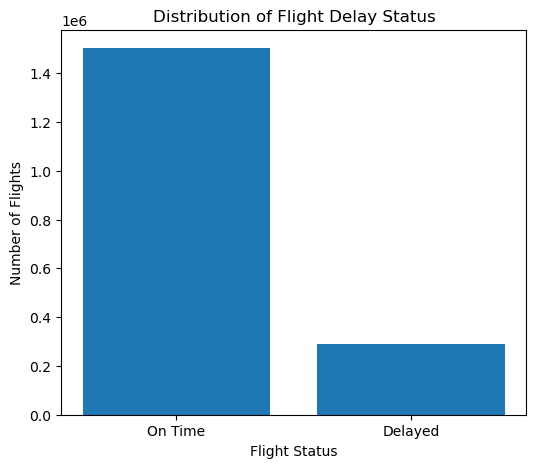

In [6]:
delay_counts = df["IS_DELAYED"].value_counts().sort_index()

delay_labels = ["On Time", "Delayed"]

plt.figure(figsize=(6,5))

plt.bar(
    delay_labels,
    delay_counts.values
)

plt.title("Distribution of Flight Delay Status")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")

plt.show()

In [7]:
delay_summary = pd.DataFrame({
    "Count": df["IS_DELAYED"].value_counts().sort_index(),
    "Percentage (%)": (
        df["IS_DELAYED"]
        .value_counts(normalize=True)
        .sort_index()
        *100
    ).round(2)
})

delay_summary.index = ["On Time","Delayed"]

delay_summary

,Count,Percentage (%)
On Time,1502892,83.88
Delayed,288736,16.12


### 📝 Interpretation

Most flights arrive on time or with only a minor delay.

Approximately **17%** of flights experience an arrival delay greater than 15 minutes, while the remaining flights arrive on time.

Although the dataset is moderately imbalanced, the delayed class still contains a large number of observations, making it suitable for machine learning classification.

### 💡 Business Insight

Only a minority of flights experience significant delays.

Predicting this minority class accurately is valuable because delayed flights can increase operational costs, passenger dissatisfaction, and scheduling disruptions.

# Business Question 2

## Which airlines operate the largest number of flights?

Understanding the distribution of flights across airlines provides context for later comparisons of delay performance.

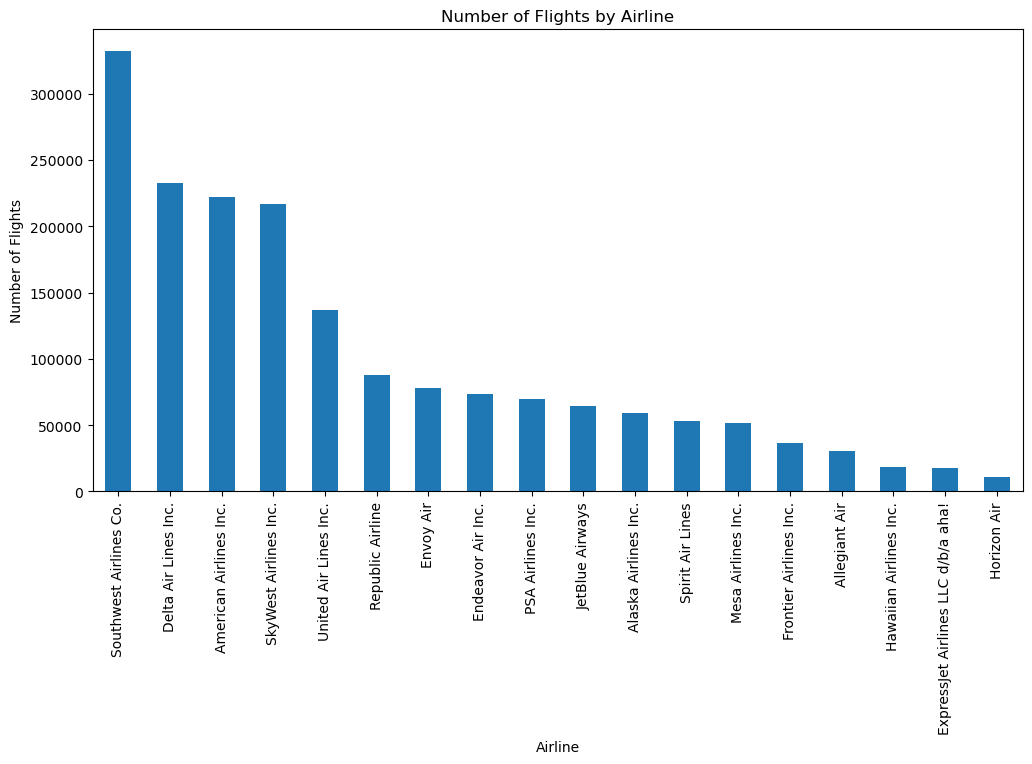

In [8]:
airline_counts = (
    df["AIRLINE"]
    .value_counts()
)

plt.figure(figsize=(12,6))

airline_counts.plot(kind="bar")

plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.xticks(rotation=90)

plt.show()

In [9]:
airline_counts.head(10)

AIRLINE
Southwest Airlines Co.    331862
Delta Air Lines Inc.      232893
American Airlines Inc.    222270
SkyWest Airlines Inc.     216923
United Air Lines Inc.     136924
Republic Airline           87490
Envoy Air                  77757
Endeavor Air Inc.          73875
PSA Airlines Inc.          69389
JetBlue Airways            64092
Name: count, dtype: int64

### 📝 Interpretation

Flight operations are not evenly distributed across airlines.

Some airlines operate substantially more flights than others, indicating that the dataset contains varying levels of representation across carriers.

### 💡 Business Insight

Airlines with larger flight volumes contribute more heavily to the dataset and may have a greater impact on overall delay patterns.

When comparing airline performance, delay **rates** should be considered rather than only the total number of delayed flights.

# Business Question 3

## At what time of day do most flights depart?

This analysis examines the distribution of departure hours to identify the busiest periods of the day.

Understanding departure patterns helps explain airport congestion and operational workload.

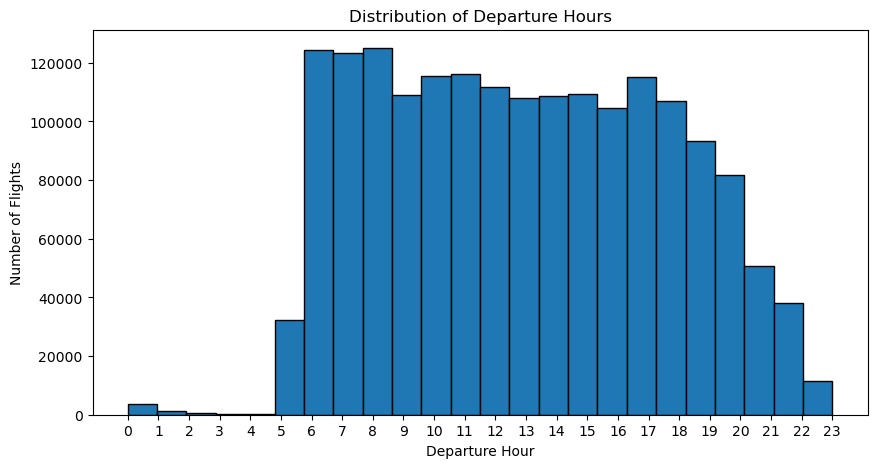

In [10]:
plt.figure(figsize=(10,5))

plt.hist(
    df["DEP_HOUR"],
    bins=24,
    edgecolor="black"
)

plt.title("Distribution of Departure Hours")
plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")

plt.xticks(range(0,24))

plt.show()

### 📝 Interpretation

Flight departures are concentrated during daytime hours, with noticeable peaks during the morning and afternoon.

Very few flights depart during late-night hours, reflecting normal airline scheduling practices.

### 💡 Business Insight

Peak departure periods correspond to the busiest airport operations. Increased traffic during these hours may contribute to delays because of runway congestion and higher demand for airport resources.

# Business Question 4

## How are flights distributed by travel distance?

This analysis explores the distribution of flight distances and identifies whether short-haul or long-haul flights dominate the dataset.

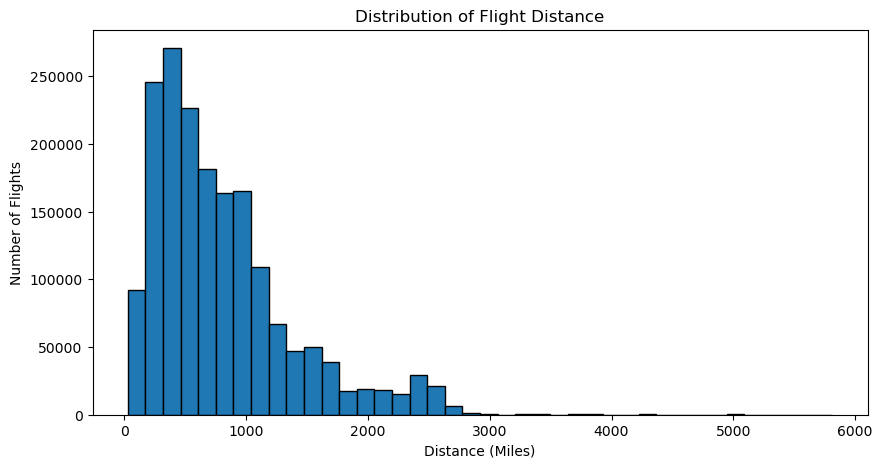

In [11]:
plt.figure(figsize=(10,5))

plt.hist(
    df["DISTANCE"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Flight Distance")
plt.xlabel("Distance (Miles)")
plt.ylabel("Number of Flights")

plt.show()

In [12]:
df["DISTANCE"].describe()

count    1.791628e+06
mean     8.020901e+02
std      5.825743e+02
min      2.900000e+01
25%      3.720000e+02
50%      6.470000e+02
75%      1.037000e+03
max      5.812000e+03
Name: DISTANCE, dtype: float64

### 📝 Interpretation

The distribution is right-skewed, indicating that most flights cover relatively short distances while fewer flights travel very long distances.

### 💡 Business Insight

Since short-haul flights represent the majority of operations, improvements in their punctuality could have the greatest overall impact on airline performance and customer satisfaction.

# Business Question 5

## How are flights distributed across seasons?

Seasonal analysis helps determine whether flight activity varies throughout the year, which may influence operational planning and delay prediction.

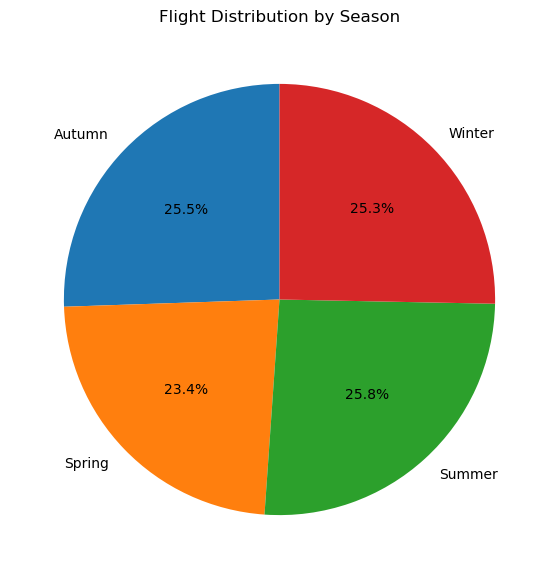

In [13]:
season_counts = (
    df["SEASON"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,7))

plt.pie(
    season_counts,
    labels=season_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Flight Distribution by Season")

plt.show()

### 📝 Interpretation

Flights are distributed across all seasons, although some seasons account for a larger share of total operations than others. These differences may reflect travel demand and airline scheduling.

### 💡 Business Insight

Seasonal travel demand may influence airport congestion and aircraft utilization, making seasonality an important feature for delay prediction.

# Business Question 6

## Which airlines experience the highest delay rates?

This analysis compares the percentage of delayed flights among the ten airlines with the highest number of flights.

Using delay rate instead of total delayed flights provides a fair comparison regardless of airline size.

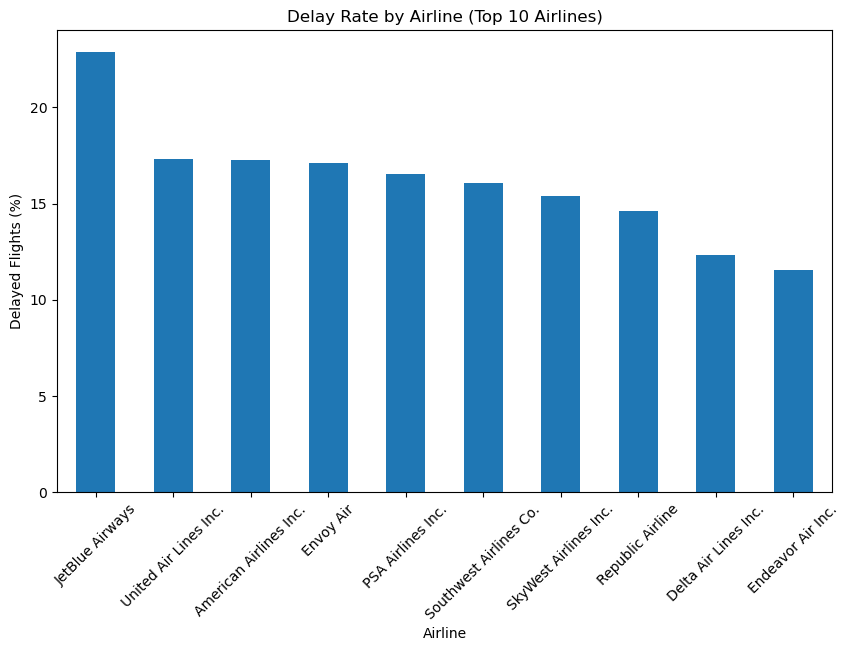

In [14]:
# Top 10 airlines by number of flights
top_airlines = df["AIRLINE"].value_counts().nlargest(10).index

delay_rate = (
    df[df["AIRLINE"].isin(top_airlines)]
    .groupby("AIRLINE")["IS_DELAYED"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))

delay_rate.plot(kind="bar")

plt.title("Delay Rate by Airline (Top 10 Airlines)")
plt.xlabel("Airline")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=45)

plt.show()

In [15]:
delay_rate.round(2)

AIRLINE
JetBlue Airways           22.87
United Air Lines Inc.     17.33
American Airlines Inc.    17.27
Envoy Air                 17.09
PSA Airlines Inc.         16.55
Southwest Airlines Co.    16.08
SkyWest Airlines Inc.     15.37
Republic Airline          14.59
Delta Air Lines Inc.      12.33
Endeavor Air Inc.         11.54
Name: IS_DELAYED, dtype: float64

Delay rates vary noticeably across airlines.

Some airlines consistently record a higher percentage of delayed flights, suggesting operational differences such as scheduling efficiency, route networks, or airport congestion.

Delay rate is a more meaningful performance indicator than the total number of delayed flights.

Airlines with higher delay rates may benefit from operational improvements and more accurate delay prediction systems.

# Business Question 7

## Does the time of departure influence flight delays?

Departure time may affect flight punctuality because congestion accumulates throughout the day.

This analysis compares delay rates across different periods of the day.

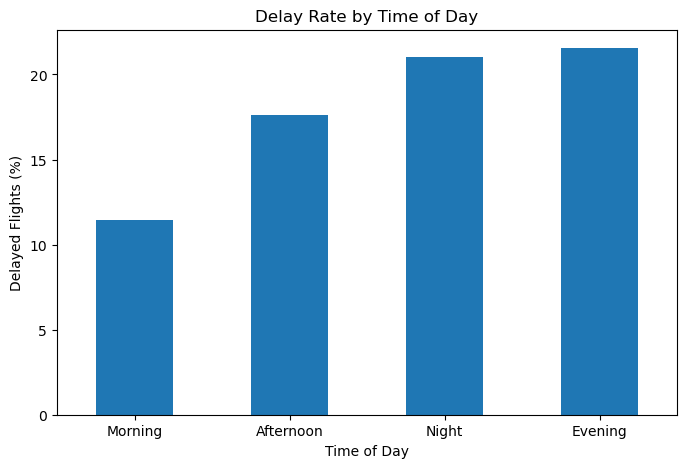

In [16]:
time_delay = (
    df.groupby("TIME_OF_DAY")["IS_DELAYED"]
    .mean()
    *100
).sort_values()

plt.figure(figsize=(8,5))

time_delay.plot(kind="bar")

plt.title("Delay Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=0)

plt.show()

In [17]:
time_delay.round(2)

TIME_OF_DAY
Morning      11.44
Afternoon    17.59
Night        21.02
Evening      21.55
Name: IS_DELAYED, dtype: float64

Delay rates differ across the day.

Flights departing later in the day often experience higher delays because delays from earlier flights can propagate through aircraft rotations and airport operations.

Departure time appears to be an important predictor of delays and should be retained as an input feature for machine learning models.

# Business Question 8

## Does flight distance influence delay frequency?

This analysis investigates whether short-haul and long-haul flights experience different delay rates.

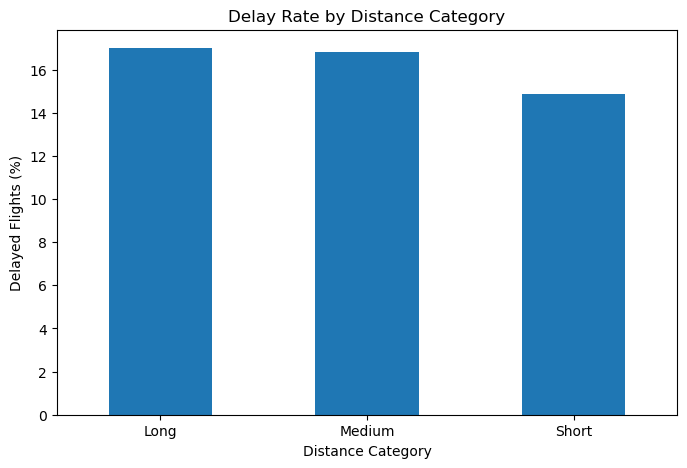

In [18]:
distance_delay = (
    df.groupby("DISTANCE_CATEGORY")["IS_DELAYED"]
    .mean()
    *100
)

plt.figure(figsize=(8,5))

distance_delay.plot(kind="bar")

plt.title("Delay Rate by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=0)

plt.show()

In [19]:
distance_delay.round(2)

DISTANCE_CATEGORY
Long      17.00
Medium    16.81
Short     14.85
Name: IS_DELAYED, dtype: float64

Delay rates vary across distance categories, indicating that flight length may influence operational performance.

Flight distance can provide useful predictive information because operational challenges differ between short-haul and long-haul routes.

# Business Question 9

## Does seasonality influence flight delays?

Travel demand changes throughout the year because of holidays, weather conditions, and tourism.

This analysis examines whether delay rates vary by season.

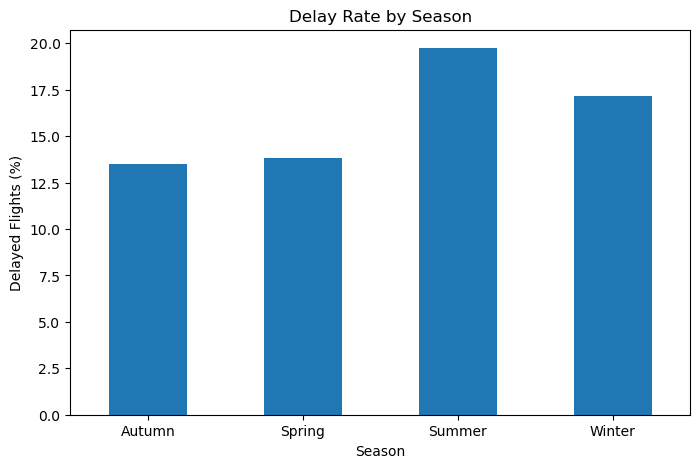

In [20]:
season_delay = (
    df.groupby("SEASON")["IS_DELAYED"]
    .mean()
    *100
)

plt.figure(figsize=(8,5))

season_delay.plot(kind="bar")

plt.title("Delay Rate by Season")
plt.xlabel("Season")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=0)

plt.show()

In [21]:
season_delay.round(2)

SEASON
Autumn    13.52
Spring    13.82
Summer    19.75
Winter    17.16
Name: IS_DELAYED, dtype: float64

# 📝 Interpretation
Seasonal differences in delay rates suggest that weather conditions and travel demand influence flight punctuality.

# 💡 Business Insight
Seasonality should be considered in predictive models because certain seasons are associated with increased operational complexity.

# Business Question 10

## Which numerical variables are most strongly correlated?

A correlation heatmap helps identify relationships among numerical variables and highlights features that may be useful for predictive modeling.

# 📝 Interpretation
Most numerical variables exhibit weak to moderate correlations.

This indicates that the dataset contains relatively independent predictors, which is generally beneficial for machine learning because it reduces redundancy among features.

# 💡 Business Insight
The correlation analysis helps identify useful predictors while also highlighting variables that may provide overlapping information. These findings will guide feature selection and model development.

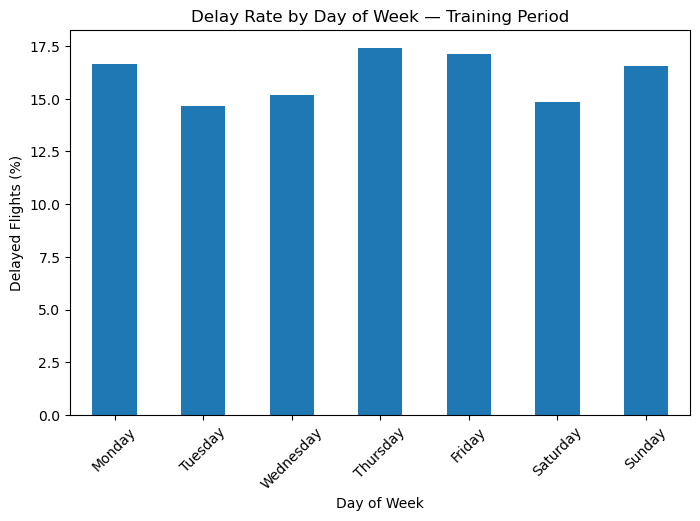

In [22]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

delay_by_day = (
    df.groupby("DAY_OF_WEEK", observed=False)["IS_DELAYED"]
    .mean()
    .reindex(day_order)
    .mul(100)
)

plt.figure(figsize=(8, 5))

delay_by_day.plot(kind="bar")

plt.title("Delay Rate by Day of Week — Training Period")
plt.xlabel("Day of Week")
plt.ylabel("Delayed Flights (%)")
plt.xticks(rotation=45)

plt.show()

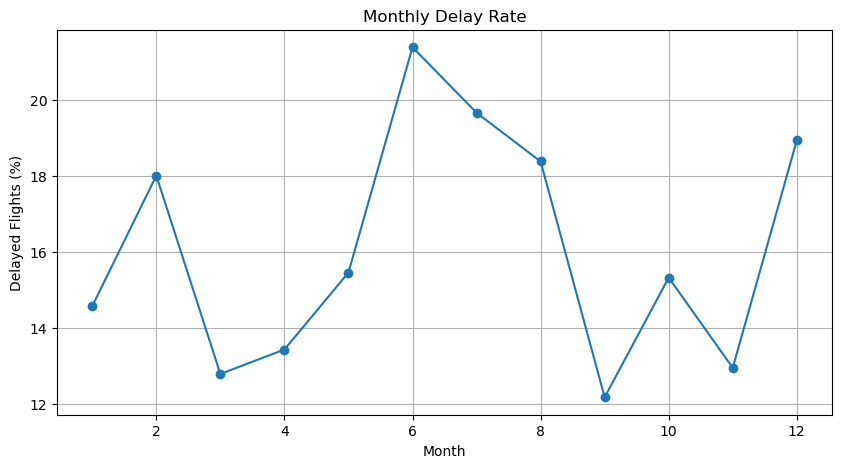

In [23]:
monthly_delay = (
    df.groupby("MONTH")["IS_DELAYED"]
      .mean() * 100
)

plt.figure(figsize=(10,5))
monthly_delay.plot(marker="o")
plt.title("Monthly Delay Rate")
plt.xlabel("Month")
plt.ylabel("Delayed Flights (%)")
plt.grid(True)
plt.show()

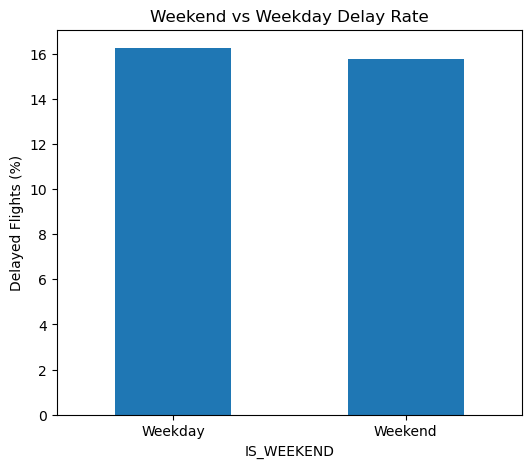

In [24]:
weekend_delay = (
    df.groupby("IS_WEEKEND")["IS_DELAYED"]
      .mean() * 100
)

plt.figure(figsize=(6,5))
weekend_delay.plot(kind="bar")
plt.xticks([0,1],["Weekday","Weekend"],rotation=0)
plt.ylabel("Delayed Flights (%)")
plt.title("Weekend vs Weekday Delay Rate")
plt.show()

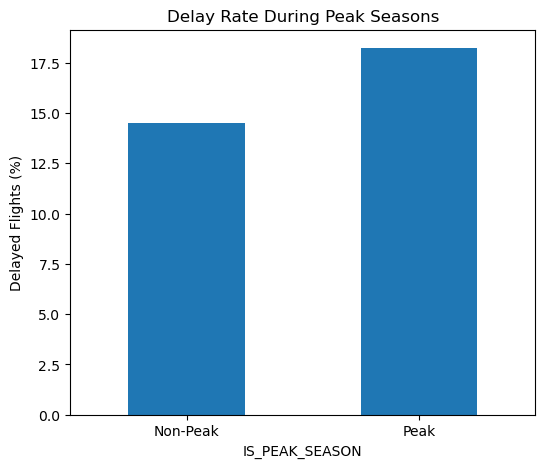

In [25]:
peak_delay = (
    df.groupby("IS_PEAK_SEASON")["IS_DELAYED"]
      .mean() * 100
)

plt.figure(figsize=(6,5))
peak_delay.plot(kind="bar")
plt.xticks([0,1],["Non-Peak","Peak"],rotation=0)
plt.ylabel("Delayed Flights (%)")
plt.title("Delay Rate During Peak Seasons")
plt.show()

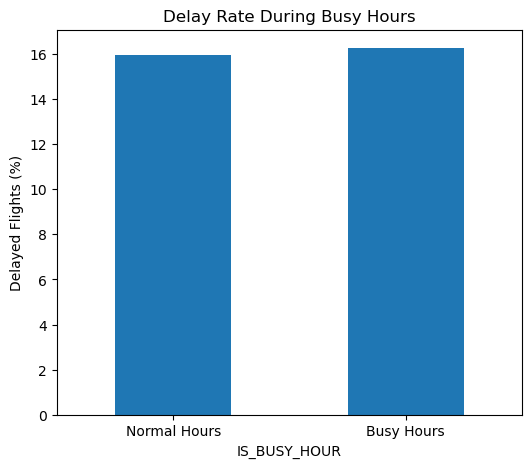

In [26]:
busy_delay = (
    df.groupby("IS_BUSY_HOUR")["IS_DELAYED"]
      .mean() * 100
)

plt.figure(figsize=(6,5))
busy_delay.plot(kind="bar")
plt.xticks([0,1],["Normal Hours","Busy Hours"],rotation=0)
plt.ylabel("Delayed Flights (%)")
plt.title("Delay Rate During Busy Hours")
plt.show()

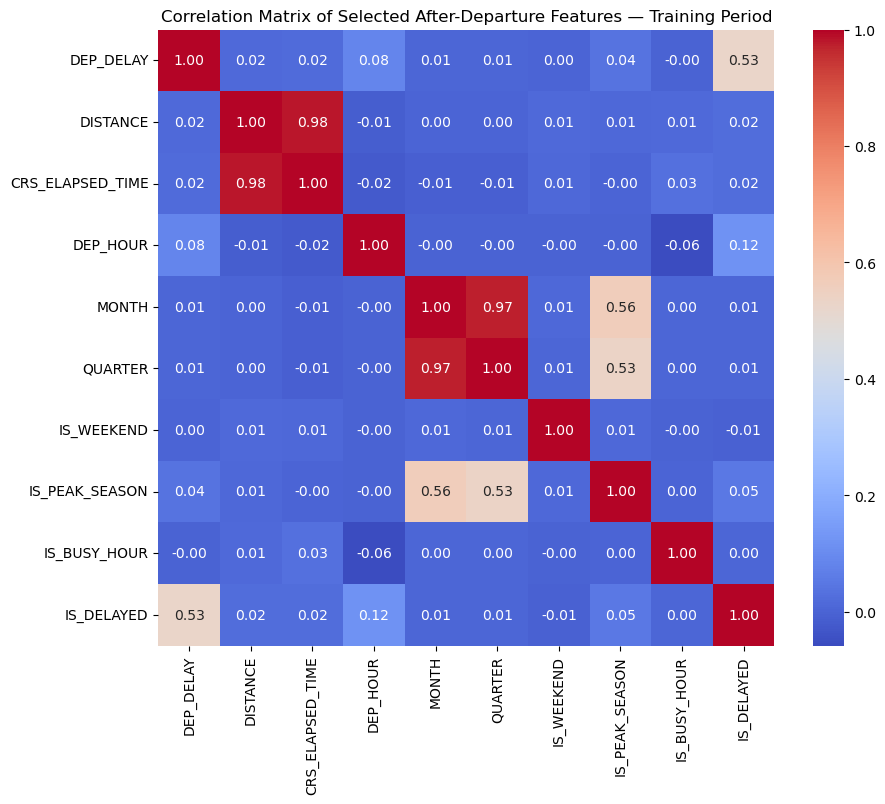

In [27]:
selected_features = [
    "DEP_DELAY",
    "DISTANCE",
    "CRS_ELAPSED_TIME",
    "DEP_HOUR",
    "MONTH",
    "QUARTER",
    "IS_WEEKEND",
    "IS_PEAK_SEASON",
    "IS_BUSY_HOUR",
    "IS_DELAYED"
]

corr = df[selected_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation Matrix of Selected After-Departure Features "
    "— Training Period"
)

plt.show()

# Key Findings

- Approximately 17% of flights are delayed by more than 15 minutes.
- Flight operations are concentrated during daytime hours.
- Delay rates vary across airlines.
- Departure time influences the likelihood of delays.
- Flight distance and seasonality appear to affect delay frequency.
- Numerical features generally exhibit low multicollinearity, making them suitable for predictive modeling.

# Notebook Summary

This notebook explored the engineered flight dataset using both univariate and bivariate analyses.

Several operational factors—including airline, departure time, seasonality, travel distance, and airport activity—were found to influence flight delays.

The insights obtained from this analysis provide a strong foundation for selecting the most informative features and developing machine learning models capable of predicting flight delays accurately.

# Overall EDA Summary

The exploratory analysis revealed several important patterns in the flight dataset.

### Main Findings

- Approximately 17% of flights arrive more than 15 minutes late.
- Flight departures are concentrated during daytime operating hours.
- Delay rates vary considerably among airlines.
- Flights departing later in the day generally experience higher delay rates.
- Seasonal and monthly variations suggest that weather and travel demand influence flight punctuality.
- Busy operating periods show a higher likelihood of delays.
- Most numerical predictors exhibit relatively low correlation with one another, indicating limited multicollinearity.

### Implications for Machine Learning

The exploratory analysis confirms that several engineered variables—including departure hour, season, peak season, busy hour, and distance—are likely to contribute useful predictive information.

These insights provide a strong justification for proceeding with feature selection and predictive model development.